# Notebook 1. Measures related to xylem vessels

In this notebook, we work on macroscope cross-section images, and measure the xylem vessel properties. To do so, we proceed as follows:
- segmentation of the vessels, using mobileSAM as a pre-processing step, followed by a filtering of the resulting objects.
- separating old and new xylem using the provided mask
- computing the properties of interest :
    - size, position, and eccentricity of xylem vessels in polar coordinates
    - new xylem width
    - new xylem vessel count and area. 

In [1]:
import scipy.ndimage as ndi
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile
import segmentation_tools as seg

%load_ext autoreload
%autoreload 2

# to mask the warnings raised from MobileSAM
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator

## 1. Segmentation of xylem vessel

### 1.1 Configuration of MobileSAM

In [2]:
model_type = "vit_t"
sam_checkpoint = "./mobile_sam.pt"

device = "cuda"#"cuda"# if torch.cuda.is_available() else "cpu"

mobile_sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
_=mobile_sam.to(device=device)

In [3]:
mask_generator = SamAutomaticMaskGenerator(mobile_sam,
                                          points_per_side=32,
                                          crop_n_layers=3,
                                        crop_overlap_ratio = 0.01,
                                          points_per_batch=16
                                          )

### 1.2 Load and segment the image

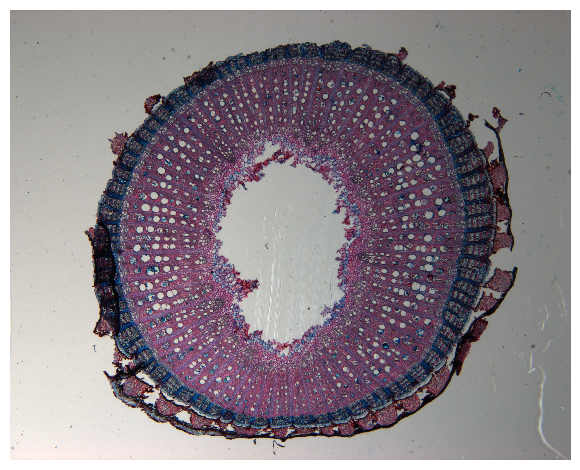

In [4]:
image = tifffile.imread('./input images/I_Month 6_Gw-10.tif')
mask_new_xylem =  plt.imread('./input images/I_Month 6_Gw-10_new_xylem_mask.png').sum(axis=2)[::-1]

plt.imshow(image)
plt.axis('off')
plt.tight_layout()

In [5]:
# Path to the result
path_SAM = './input images/I_Month 6_Gw-10_SAM.tif'

if os.path.exists(path_SAM)==False:
    print('SAM segmentation ongoing...')
    print('(This step may take time depending on your configuration)')
    masks = mask_generator.generate(image)
    print('SAM segmentation: done !')
    sam_mask = seg.make_anns_img(masks)
    tiffile.imwrite(path_SAM,sam_mask)
else:
    print('SAM segmentation already made, loading the result.')
    sam_mask = tifffile.imread(path_SAM)

SAM segmentation already made, loading the result.


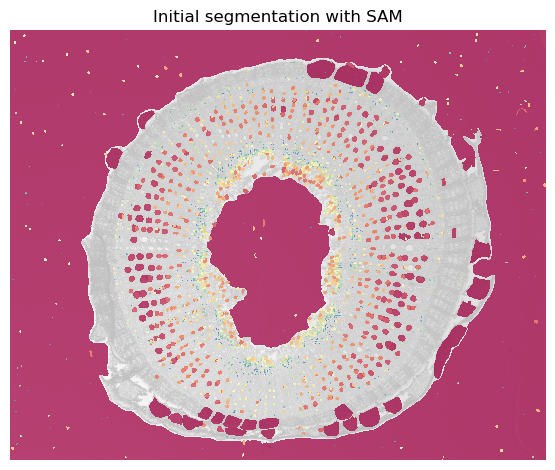

In [6]:
seg.display(image,sam_mask)
plt.title('Initial segmentation with SAM');
plt.tight_layout()

### 1.3 Finer segmentation

We need some physical quantities to determine what is a large/small vessel. Manual measures on a few examples yields the following:
- Riesling:
    - area_max = 7887 µm2
    - too_close_distance = 4.8 (distance between marrow cells)
    - area_min = 170 µm2
- Gewurztraminer:
    - area_max = 14000 µm2
    - too_close_distance = 4.3 µm
    - area_min = 308 µm2

We choose to use the less conservative bounds to yield minimal false rejection, hence the values chosen below.

In [7]:
area_max = 14000
too_close_distance = 4.3
area_min = 170
zoom = 1 # can be used to accelerate some computations
final_segmentation=seg.vessel_segmentation_after_sam(sam_mask,zoom,area_max,too_close_distance,area_min)

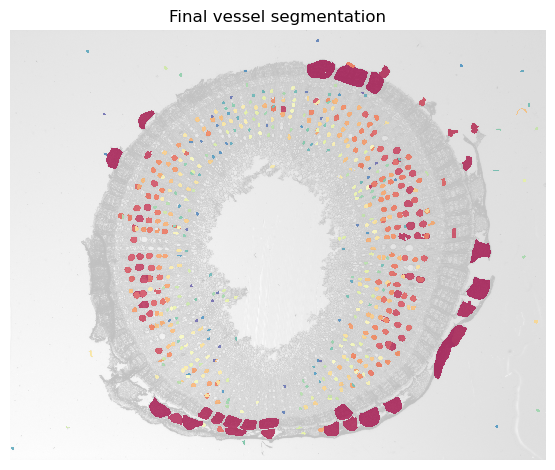

In [8]:
seg.display(image,final_segmentation)
plt.title('Final vessel segmentation');
plt.tight_layout()

Note that some non-xylem areas may be highlighted still. Those will be removed when considering the new xylem mask, that acts as an outer border for objects of interests.

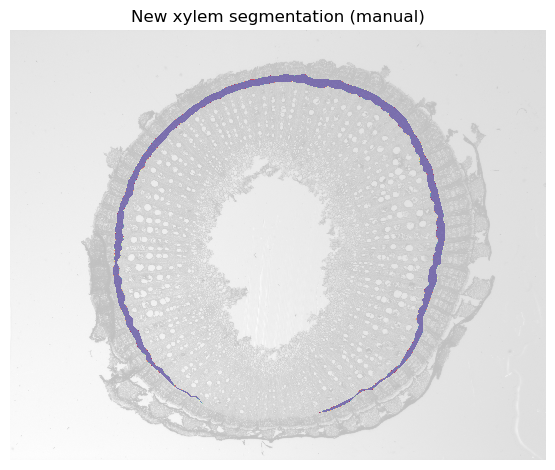

In [9]:
seg.display(image,mask_new_xylem)
plt.title('New xylem segmentation (manual)');
plt.tight_layout()

### 1.4 Extracting the properties in polar coordinates

In [10]:
areas,ecc,count = seg.get_area_count(final_segmentation,mask_new_xylem)

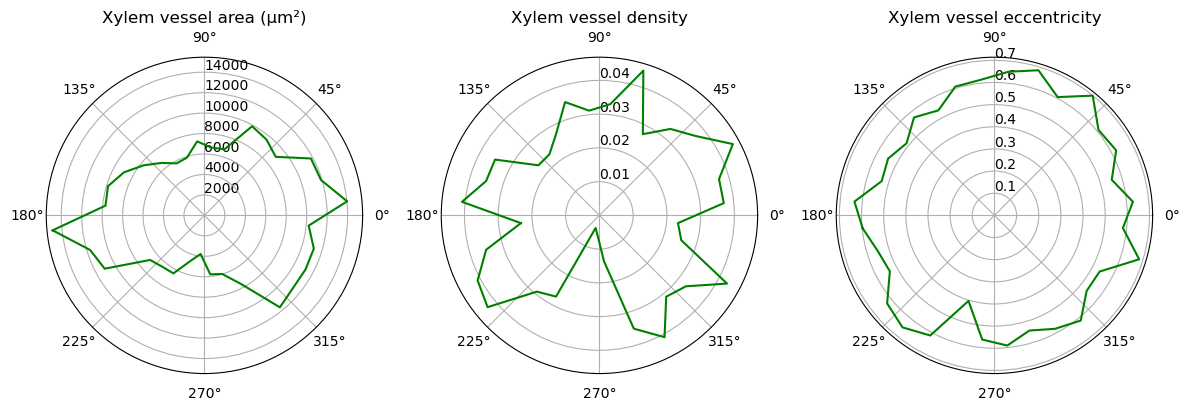

In [11]:
seg.display_polar_measurements(areas,count,ecc)

## 2. New xylem properties

### 2.1 New xylem thickness


In [12]:
image = tifffile.imread('input images/I_Month 3_Gw-06.tif')
mask_new_xylem = plt.imread("input images/I_Month 3_Gw-06_new_xylem_mask.png").sum(axis=2)[::-1]

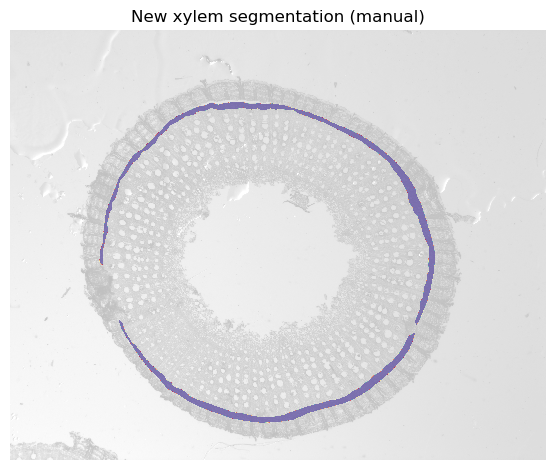

In [13]:
seg.display(image,mask_new_xylem)
plt.title('New xylem segmentation (manual)');
plt.tight_layout()

In [14]:
new_xylem_thickness = seg.get_phloem_width(mask_new_xylem)
print('Estimated new xylem thickness : %.2f µm.'%new_xylem_thickness)

Estimated new xylem thickness : 130.16 µm.


### 2.2 New xylem vessel counting and area

In [15]:
image = tifffile.imread('input images/I_Month 3_Gw-06.tif')
final_segmentation = tifffile.imread('input images/I_Month 3_Gw-06_seg.tif')
mask_new_xylem = plt.imread("input images/I_Month 3_Gw-06_new_xylem_mask.png").sum(axis=2)[::-1]

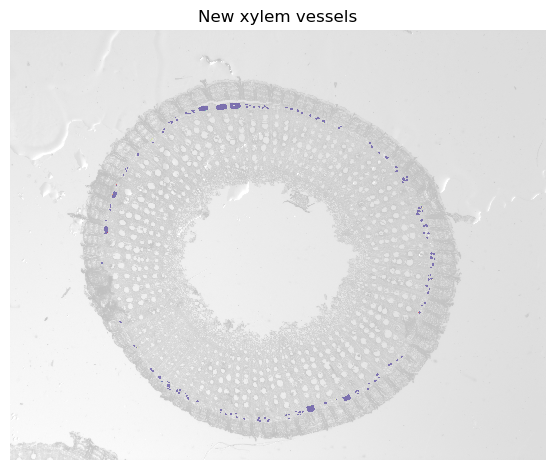

In [16]:
seg.display(image,(final_segmentation>0)*mask_new_xylem)
plt.title('New xylem vessels');
plt.tight_layout()

In [17]:
area, number = seg.get_new_xylem_area_number(mask_new_xylem,final_segmentation)
print('We observe %.0f new xylem vessels with an average area of %.2f µm^2'%(number,area)) 

We observe 105 new xylem vessels with an average area of 1838.84 µm^2
